# Prueba Microcredencial Gestión de Carteras con Python
20/04/2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import missingno as mso
import cvxpy as cp
import statsmodels.api as sm
from pandas_datareader import data as pdr
from scipy.linalg import sqrtm

## Preparación de datos
Descarga de datos

In [2]:
tickers = [
    "AAPL",  # Apple Inc. (Tecnología)
    "BTC-USD",  # Bitcoin (Activo de riesgo/liquidez global)
    "GLD",  # SPDR Gold Shares (Oro, refugio de valor)
    "DE",  # Deere & Co (Líder en tecnología agrícola y maquinaria)
    "UNP",  # Union Pacific (Ferrocarriles, columna vertebral logística de EE.UU.)
    "LIN",  # Linde plc (Gases industriales, esencial para la producción global)
    "SHW",  # Sherwin-Williams (Construcción y mercado inmobiliario)
    "COST",  # Costco Wholesale (Consumo masivo y modelo de suscripción)
    "TJX",  # TJX Companies (Retail de descuento, fuerte en ciclos de inflación)
    "LULU",  # Lululemon Athletica (Consumo discrecional premium y estilo de vida)
    "UNH",  # UnitedHealth Group (Servicios y seguros de salud, pilar financiero)
    "ISRG",  # Intuitive Surgical (Vanguardia en cirugía robótica)
    "SYK",  # Stryker Corp (Equipamiento médico y envejecimiento poblacional)
    "NEE",  # NextEra Energy (Líder en utilidades renovables y transición energética)
    "AMT",  # American Tower (REIT de infraestructura para telecomunicaciones/5G)
    "SPGI",  # S&P Global (Calificaciones crediticias y dueños de índices)
    "V",  # Visa (Red global de pagos y digitalización del efectivo)
    "ICE",  # Intercontinental Exchange (Infraestructura de mercados y dueños del NYSE)
]
data = yf.download(tickers, start="2016-01-01", end="2026-04-15", auto_adjust=True)["Close"]

[*********************100%***********************]  18 of 18 completed


In [3]:
data_idx = yf.download("SPY", start=data.index.min(), end=data.index.max(), auto_adjust=True)["Close"]


[*********************100%***********************]  1 of 1 completed


Limpieza

In [4]:
data = data.dropna(axis=1, how="all")
data = data.dropna(axis=0, how="any")

<Axes: >

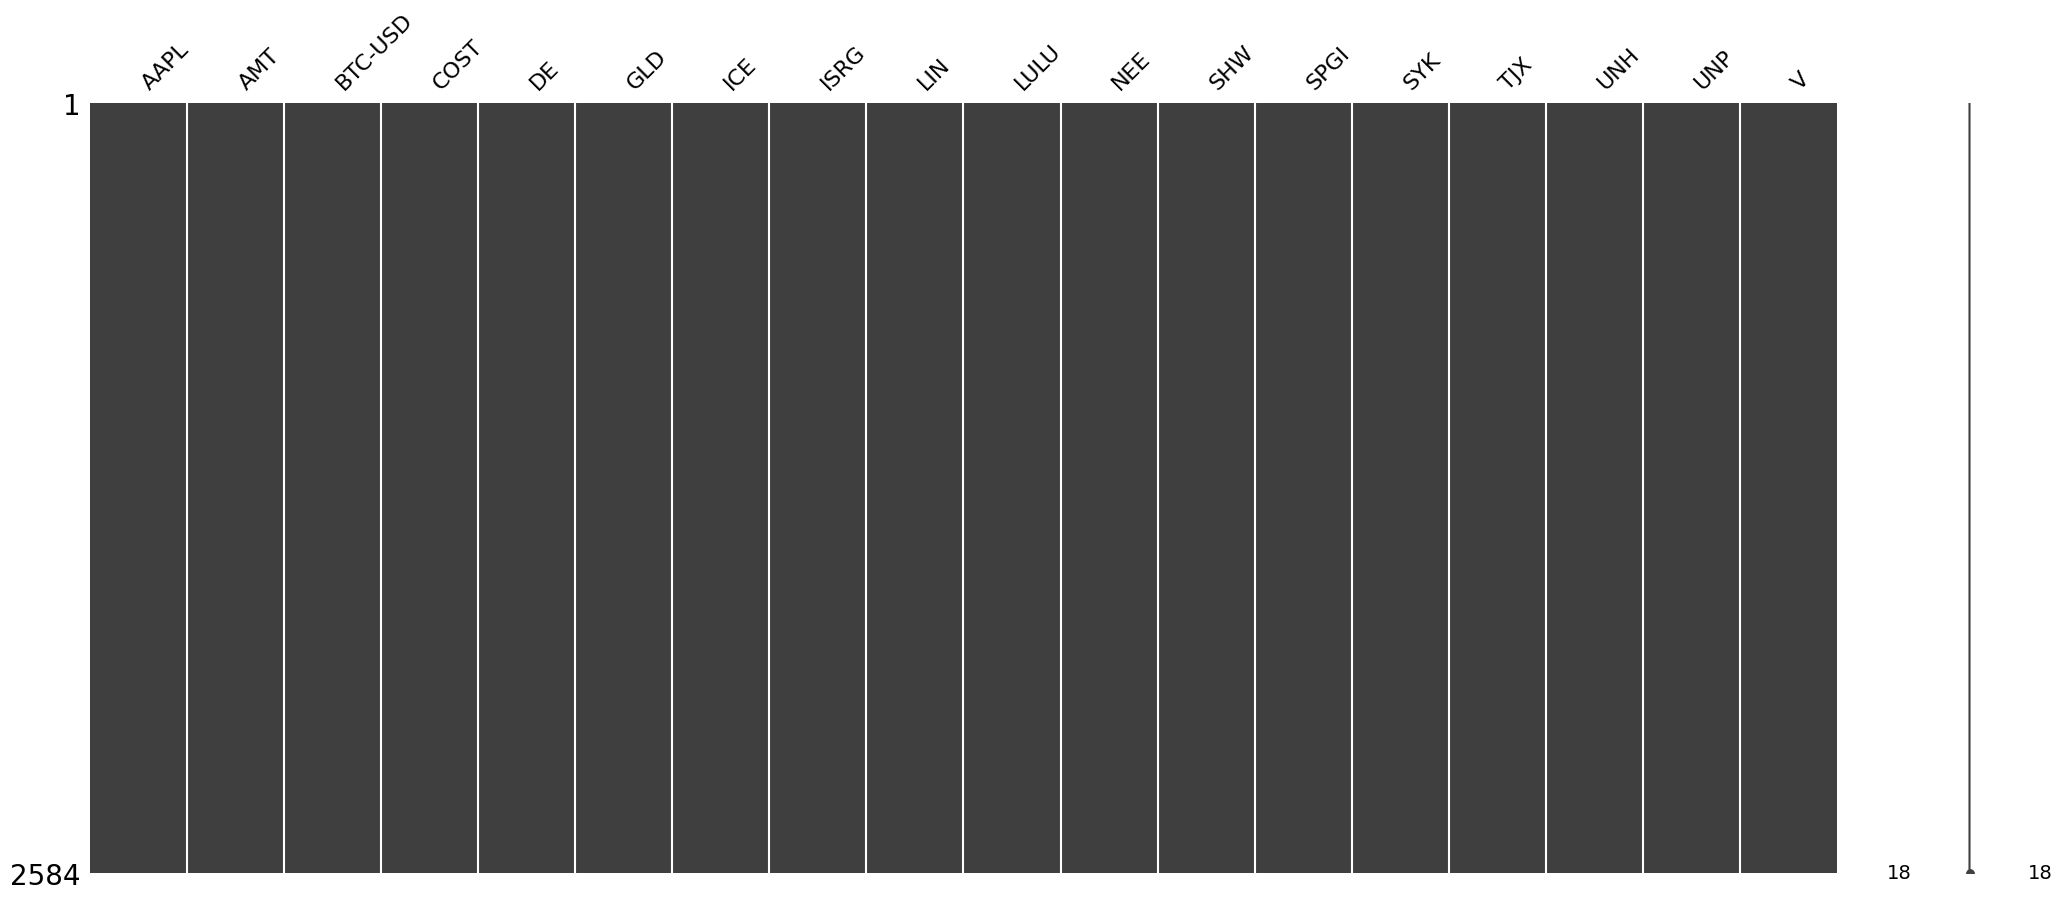

In [5]:
mso.matrix(data)


Alineamos los dataframes de precios de los activos con el del índice.

In [6]:
data, data_idx = data.align(data_idx, join="inner", axis=0)

## Cálculo de carteras

Crea una función llamada `cartera_min_vol` que calcule la cartera de mínima volatilidad.

* Parámetros de entrada:
    * DataFrame de retornos de los activos.
* Resultado:
    * Vector de pesos de la cartera.

In [7]:
def cartera_min_vol(ret):
    """Función que calcula la cartera de mínima varianza para un DataFrame de rendimientos
    ret: DataFrame de rendimientos
    Retorna pesos_ajustados: Array con los pesos de la cartera de mínima varianza"""

    if isinstance(ret, pd.DataFrame):  # Verifico que el argumento sea un DataFrame
        num_act = ret.shape[1]
        matriz_cov = ret.cov().to_numpy()

        # Variables de decisión
        pesos = cp.Variable(num_act)

        # Restricciones
        constraints = [
            pesos >= 0,
            cp.sum(pesos) == 1,
        ]

        riesgo = cp.quad_form(pesos, matriz_cov)  # Riesgo de la cartera
        objective = cp.Minimize(riesgo)  # Minimizar la varianza

        # Problema y resuelvo
        prob = cp.Problem(objective, constraints)
        resultado = prob.solve()

        pesos_ajustados = np.array(
            [np.round(x, 3) if x > 10**-4 else 0 for x in pesos.value]
        )  # Pongo a cero los pesos menores a 10^-4 y redondeo a 3 decimales

        return pesos_ajustados

    else:
        raise ValueError(
            "La función cartera_min_vol solo acepta un DataFrame como argumento"
        )  # Si el argumento no es un DataFrame, lanzo un error

Crea una función llamada `cartera_max_sharpe` que calcule la cartera de máximo ratio de Sharpe.

* Parámetros de entrada:
    * DataFrame de retornos de los activos.
    * Tasa libre de riesgo.
* Resultado:
    * Vector de pesos de la cartera.

In [8]:
def cartera_max_sharpe(ret, ret_rf):
    """Función que calcula la cartera de máximo índice de Sharpe para un DataFrame de rendimientos
    ret: DataFrame de rendimientos
    ret_rf: Rendimiento del activo libre de riesgo
    Retorna pesos_ajustados: Array con los pesos de la cartera de máximo índice de Sharpe"""

    if isinstance(ret, pd.DataFrame):
        num_act = ret.shape[1]
        matriz_cov = ret.cov().to_numpy()
        retornos_esperados = ret.mean()

        # Variable de decisión (pesos del portafolio)
        x = cp.Variable(num_act)
        # Riesgo (desviación estándar) del portafolio
        riesgo = cp.quad_form(x, matriz_cov)

        # Cálculo de pi como retornos esperados menos la rantabilidad del activo libre de riesgo
        pi = np.array(retornos_esperados - ret_rf)

        # Restricciones
        constraints = [
            pi @ x == 1,  # para que el numerador sea 1
            x >= 0,
        ]  # sin posiciones cortas

        objective = cp.Minimize(riesgo)  # Minimizo el riesgo

        # Problema de optimización
        problema = cp.Problem(objective, constraints)

        # Resolver el problema
        resultado = problema.solve()

        # Normalizo los pesos
        pesos = x.value
        pesos /= pesos.sum()

        pesos_ajustados = np.array([np.round(x, 3) if x > 10**-4 else 0 for x in pesos])

        return pesos_ajustados

    else:
        raise ValueError("La función cartera_max_sharpe solo acepta un DataFrame como argumento")

Crea una función llamada `cartera_risk_parity` que calcule la cartera Risk Parity.

* Parámetros de entrada:
    * DataFrame de retornos de los activos.
* Resultado:
    * Vector de pesos de la cartera.

In [9]:
def cartera_risk_parity(ret):
    """
    Función que calcula la cartera de riesgo paridad para un DataFrame de rendimientos
    ret: DataFrame de rendimientos
    Retorna pesos_ajustados: Array con los pesos de la cartera de riesgo paridad"""

    if isinstance(ret, pd.DataFrame):
        num_act = ret.shape[1]
        matriz_cov = ret.cov().to_numpy()
        retornos_esperados = ret.mean().to_numpy()

        b = 1 / num_act

        x = cp.Variable(num_act)
        gamma = cp.Variable(num_act, nonneg=True)
        psi = cp.Variable(nonneg=True)

        z = matriz_cov @ x

        obj = cp.pnorm(b**0.5 * psi - gamma, p=2)
        ret = retornos_esperados.T @ x

        constraints = [cp.sum(x) == 1, x >= 0, cp.SOC(psi, sqrtm(matriz_cov) @ x)]

        for i in range(num_act):
            constraints += [cp.SOC(x[i] + z[i], cp.vstack([2 * gamma[i], x[i] - z[i]]))]

        objective = cp.Minimize(obj * 1000)
        prob = cp.Problem(objective, constraints)
        prob.solve()

        pesos_ajustados = np.array([np.round(xi, 3) if xi > 10**-4 else 0 for xi in x.value])

        return pesos_ajustados

    else:
        raise ValueError("La función cartera_risk_parity solo acepta un DataFrame como argumento")

Crea una función llamada `cartera_min_cvar` que calcule la cartera de mínimo CVaR.

* Parámetros de entrada:
    * DataFrame de retornos de los activos.
    * Nivel de confianza para el cálculo del CVaR.
* Resultado:
    * Vector de pesos de la cartera.

In [10]:
def cartera_min_cvar(ret, alpha=0.5):
    """Función que calcula la cartera de mínimo CVaR para un DataFrame de rendimientos
    ret: DataFrame de rendimientos
    alpha: Nivel de confianza
    Retorna pesos_ajustados: Array con los pesos de la cartera de mínimo CVaR"""

    if isinstance(ret, pd.DataFrame):  # Verifico que el argumento sea un DataFrame
        retornos = ret.to_numpy()
        retornos_esperados = ret.mean().to_numpy()

        num_data, num_act = retornos.shape  # Número de datos y número de activos

        pesos = cp.Variable(num_act)
        t = cp.Variable()  # VaR
        ui = cp.Variable(num_data)  # Exceso de pérdida con respecto al VaR

        riesgo = t + cp.sum(ui) / (alpha * num_data)  # CVaR
        retornos_cartera = retornos_esperados.T @ pesos

        restricciones = [
            -retornos @ pesos - t - ui <= 0,  # Las pérdidas son menores que VaR más el exceso de pérdida
            ui >= 0,  # Los excesos son positivos
            cp.sum(pesos) == 1,
            pesos >= 0,  # No se pueden tener posiciones cortas
        ]

        objective = cp.Minimize(riesgo)

        # Solve the problem
        prob = cp.Problem(objective, restricciones)
        cvar95_min_cvar = prob.solve()

        pesos_ajustados = np.array(
            [np.round(x, 3) if x > 10**-4 else 0 for x in pesos.value]
        )  # Pongo a cero los pesos menores a 10^-4 y redondeo a 3 decimales

        return pesos_ajustados

    else:
        raise ValueError("La función cartera_min_cvar solo acepta un DataFrame como argumento")

## Rebalanceo de carteras

* Vamos a rebalancear las carteras el primer dia laborable de cada mes.
* Para calcular los pesos de cada cartera vamos a utilizar todos los datos disponibles hasta el momento del rebalanceo.
* El primer rebalanceo se realizará el 01/02/2019.
* Suponemos que no hay costes de transacción.
* Suponemos que el capital inicial es de 1.000.000€.
* Para el cálculo del ratio de Sharpe utilizamos una tasa libre de riesgo del 0.0% anual.
* Para el cálculo del CVaR utilizamos un nivel de confianza del 95%.

In [11]:
# Para establecer una periodicidad primer día hábil de mes cada dos meses (2 BMS).
fechas_rebalanceo = pd.date_range(start=data.index.min(), end=data.index.max(), freq="2BMS")
fechas_rebalanceo = fechas_rebalanceo[fechas_rebalanceo >= "2019-02-01"]

In [12]:
fechas_rebalanceo


DatetimeIndex(['2019-02-01', '2019-04-01', '2019-06-03', '2019-08-01',
               '2019-10-01', '2019-12-02', '2020-02-03', '2020-04-01',
               '2020-06-01', '2020-08-03', '2020-10-01', '2020-12-01',
               '2021-02-01', '2021-04-01', '2021-06-01', '2021-08-02',
               '2021-10-01', '2021-12-01', '2022-02-01', '2022-04-01',
               '2022-06-01', '2022-08-01', '2022-10-03', '2022-12-01',
               '2023-02-01', '2023-04-03', '2023-06-01', '2023-08-01',
               '2023-10-02', '2023-12-01', '2024-02-01', '2024-04-01',
               '2024-06-03', '2024-08-01', '2024-10-01', '2024-12-02',
               '2025-02-03', '2025-04-01', '2025-06-02', '2025-08-01',
               '2025-10-01', '2025-12-01', '2026-02-02', '2026-04-01'],
              dtype='datetime64[ns]', freq='2BMS')

In [13]:
rf = 0.0
confianza_cvar = 0.95
pesos_min_vol = {}
pesos_max_sharpe = {}
pesos_risk_parity = {}
pesos_min_cvar = {}

for fecha in fechas_rebalanceo:
    # Filtrado de la serie de precios hasta el dia antes del rebalanceo.
    precios_hasta_fecha = data[data.index < fecha]
    precios_hasta_fecha_idx = data_idx[data_idx.index < fecha]
    # Cálculo de los retornos logarítmicos hasta el día antes del rebalanceo.
    ret_hasta_fecha = np.log(precios_hasta_fecha).diff().dropna()
    ret_hasta_fecha_idx = np.log(precios_hasta_fecha_idx).diff().dropna()
    # Cálculo de los pesos de cada cartera.
    pesos_min_vol[fecha] = cartera_min_vol(ret=ret_hasta_fecha)
    pesos_max_sharpe[fecha] = cartera_max_sharpe(ret=ret_hasta_fecha, ret_rf=rf)
    pesos_risk_parity[fecha] = cartera_risk_parity(ret=ret_hasta_fecha)
    pesos_min_cvar[fecha] = cartera_min_cvar(ret=ret_hasta_fecha, alpha=1 - confianza_cvar)

# Convertimos los diccionarios de pesos en DataFrames para facilitar su uso posterior.
pesos_min_vol_df = pd.DataFrame(pesos_min_vol).T
pesos_min_vol_df.columns = data.columns
pesos_max_sharpe_df = pd.DataFrame(pesos_max_sharpe).T
pesos_max_sharpe_df.columns = data.columns
pesos_risk_parity_df = pd.DataFrame(pesos_risk_parity).T
pesos_risk_parity_df.columns = data.columns
pesos_min_cvar_df = pd.DataFrame(pesos_min_cvar).T
pesos_min_cvar_df.columns = data.columns

In [14]:
pesos_min_vol_df


Ticker,AAPL,AMT,BTC-USD,COST,DE,GLD,ICE,ISRG,LIN,LULU,NEE,SHW,SPGI,SYK,TJX,UNH,UNP,V
2019-02-01,0.003,0.053,0.009,0.048,0.000,0.454,0.110,0.0,0.025,0.006,0.129,0.036,0.000,0.000,0.054,0.039,0.034,0.000
2019-04-01,0.005,0.054,0.009,0.044,0.000,0.451,0.114,0.0,0.021,0.008,0.134,0.036,0.000,0.000,0.054,0.032,0.036,0.004
2019-06-03,0.011,0.048,0.008,0.042,0.000,0.453,0.117,0.0,0.016,0.008,0.138,0.038,0.003,0.000,0.052,0.024,0.037,0.005
2019-08-01,0.016,0.050,0.007,0.039,0.000,0.444,0.116,0.0,0.015,0.008,0.137,0.034,0.004,0.000,0.062,0.028,0.040,0.000
2019-10-01,0.017,0.039,0.007,0.035,0.004,0.444,0.106,0.0,0.021,0.008,0.139,0.027,0.000,0.000,0.067,0.037,0.048,0.000
2019-12-02,0.019,0.037,0.007,0.039,0.006,0.448,0.098,0.0,0.025,0.007,0.131,0.024,0.000,0.000,0.068,0.040,0.051,0.000
2020-02-03,0.017,0.034,0.007,0.042,0.008,0.449,0.095,0.0,0.027,0.006,0.130,0.025,0.000,0.000,0.071,0.040,0.048,0.000
2020-04-01,0.016,0.024,0.000,0.134,0.000,0.637,0.060,0.0,0.026,0.000,0.000,0.005,0.000,0.013,0.020,0.000,0.061,0.006
2020-06-01,0.017,0.019,0.000,0.140,0.000,0.647,0.069,0.0,0.019,0.000,0.000,0.006,0.000,0.000,0.018,0.000,0.067,0.000
2020-08-03,0.009,0.017,0.000,0.146,0.000,0.646,0.069,0.0,0.017,0.000,0.000,0.004,0.000,0.000,0.022,0.000,0.068,0.000


Calculamos los retornos de cada una de las carteras a partir de los pesos y los retornos de los activos

In [15]:
px = data.iloc[data.index.get_loc(pesos_min_vol_df.index[0]) - 1 :, :]
retornos_activos_select = np.log(px).diff().dropna()
retornos_indice = np.log(data_idx.loc[px.index]).diff().dropna()

In [16]:
pesos_min_vol_daily_df = pesos_min_vol_df.reindex(index=retornos_activos_select.index, method="ffill")
pesos_max_sharpe_daily_df = pesos_max_sharpe_df.reindex(index=retornos_activos_select.index, method="ffill")
pesos_risk_parity_daily_df = pesos_risk_parity_df.reindex(index=retornos_activos_select.index, method="ffill")
pesos_min_cvar_daily_df = pesos_min_cvar_df.reindex(index=retornos_activos_select.index, method="ffill")


In [17]:
pesos_min_vol_daily_df.shape, retornos_activos_select.shape

((1808, 18), (1808, 18))

In [18]:
retornos_min_vol = pd.DataFrame(
    np.matrix(retornos_activos_select.values @ pesos_min_vol_daily_df.values.T).diagonal().T,
    index=retornos_activos_select.index,
    columns=["min_vol"],
)
retornos_max_sharpe = pd.DataFrame(
    np.matrix(retornos_activos_select.values @ pesos_max_sharpe_daily_df.values.T).diagonal().T,
    index=retornos_activos_select.index,
    columns=["max_sharpe"],
)
retornos_risk_parity = pd.DataFrame(
    np.matrix(retornos_activos_select.values @ pesos_risk_parity_daily_df.values.T).diagonal().T,
    index=retornos_activos_select.index,
    columns=["risk_parity"],
)
retornos_min_cvar = pd.DataFrame(
    np.matrix(retornos_activos_select.values @ pesos_min_cvar_daily_df.values.T).diagonal().T,
    index=retornos_activos_select.index,
    columns=["min_cvar"],
)

Graficamos la evolución de cada una de las carteras y del índice para comparar su desempeño a lo largo del tiempo, puponiendo que invertimos 1 dólar al inicio del período.

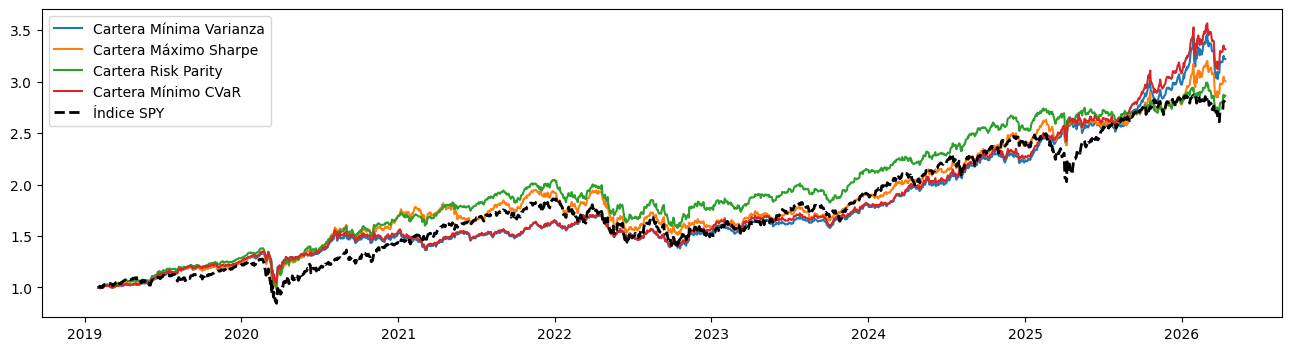

In [19]:
plt.figure(figsize=(16, 4))
plt.plot(np.exp(retornos_min_vol.cumsum()), label="Cartera Mínima Varianza")
plt.plot(np.exp(retornos_max_sharpe.cumsum()), label="Cartera Máximo Sharpe")
plt.plot(np.exp(retornos_risk_parity.cumsum()), label="Cartera Risk Parity")
plt.plot(np.exp(retornos_min_cvar.cumsum()), label="Cartera Mínimo CVaR")
plt.plot(np.exp(retornos_indice.cumsum()), label="Índice SPY", color="black", linestyle="--", linewidth=2)
plt.legend()
plt.show()